# Fitting spectra, including Raman Scattering corrections 

## This notebook demonstrates how to fit an input spectrum, allowing for Raman affects 

## v1


In [5]:
from importlib import reload
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d

from ocpy.utils import plotting
from ocpy.hydrolight import loisel23

from bing.rt import raman
from bing.rt import rrs
from bing.rt import defs as rt_defs
from bing import rt as bing_rt
from bing.fitting import l23 as fit_l23
from bing.parameters import standard
from bing import plotting as bing_plot
from bing import evaluate as bing_eval

%matplotlib inline

# Fit first without Raman

In [3]:
idx = 170
p = standard.expb_pow(satellite='PACE', add_noise=False, variable_Gordon=False)
chains, models, prep_dict, idx, extras = fit_l23.fit_one(p, idx)

idx=170
Running burn-in


100%|█████████████████████████████████████| 1000/1000 [00:01<00:00, 515.38it/s]


Running full model


100%|███████████████████████████████████| 40000/40000 [01:21<00:00, 493.68it/s]


## Show fit

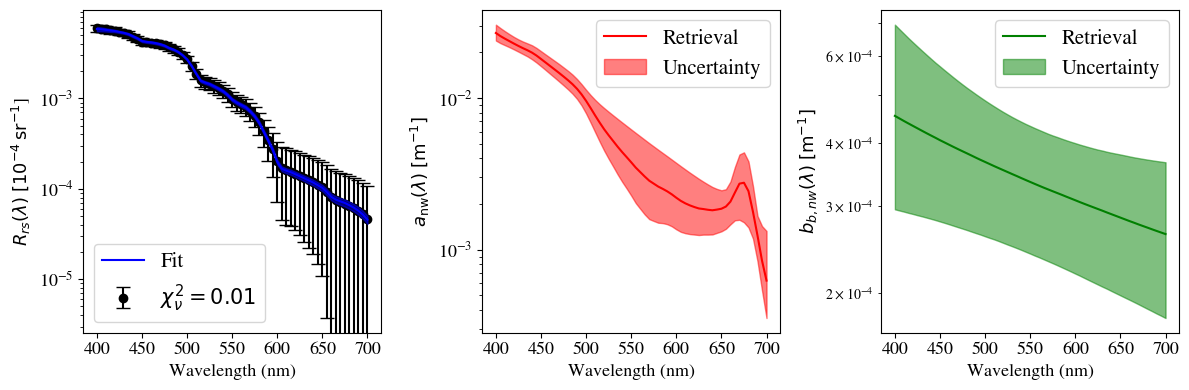

In [7]:
reload(bing_plot)
rt_dict = rt_defs.rt_dict_from_p(p)
_ = bing_plot.show_fits(models, chains, rt_dict, None, None,
                figsize=(12,4), fontsize=13., show=True,
                Rrs_true=dict(wave=models[0].wave, spec=prep_dict['model_Rrs'], var=prep_dict['model_varRrs']),
                log_abb=True )

## Stats

In [8]:
stats = bing_eval.calc_stats(chains, names=models[0].pnames+models[1].pnames)
stats

{'names': ['Adg', 'Sdg', 'Aph', 'Bnw', 'beta'],
 'med': array([-1.638464 ,  0.0132822, -2.176271 , -3.5122144,  0.9880509],
       dtype=float32),
 'p14': array([-1.7078917 ,  0.01058126, -2.7975638 , -3.6044452 ,  0.28649223],
       dtype=float32),
 'p86': array([-1.557759  ,  0.01780562, -1.9908342 , -3.4346893 ,  1.7060193 ],
       dtype=float32)}

# Raman time 

In [5]:
p_R = standard.expb_pow(satellite='PACE', add_noise=False, variable_Gordon=True, include_Raman=True)
chains_R, models_R, prep_dict_R, idx, extras_R = fit_l23.fit_one(p_R, idx)

idx=170
Running burn-in


100%|█████████████████████████████████████| 1000/1000 [00:01<00:00, 541.83it/s]


Running full model


100%|███████████████████████████████████| 40000/40000 [01:18<00:00, 510.61it/s]


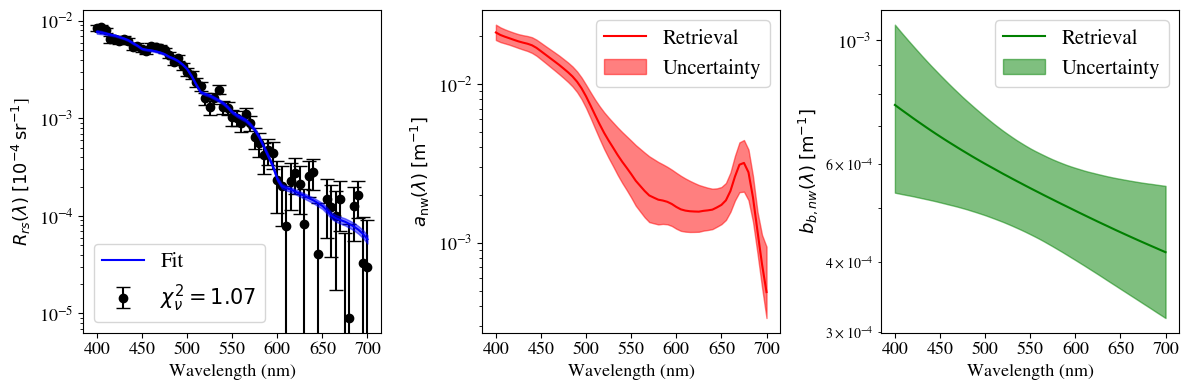

In [6]:
_ = bing_plot.show_fits(models_R, chains_R,  None, None,
                figsize=(12,4), fontsize=13., show=True,
                Rrs_true=dict(wave=models[0].wave, spec=prep_dict_R['model_Rrs'], var=prep_dict_R['model_varRrs']),
                log_abb=True )